<a href="https://colab.research.google.com/github/FrancescaPorcellii/Trajectory-Prediction/blob/main/Trajectory_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset

In [161]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
%%bash
cd "/content/drive/MyDrive/Colab Notebooks"
unzip -o "man-truckscenes_*.zip" -d "/content/man-truckscenes"

Process is interrupted.


Installing devkit

In [163]:
# Install devkit (if not done already)
!pip install -U "truckscenes-devkit[all]"

In [ ]:
%%bash
ls


drive
man-truckscenes
sample_data


In [164]:
from truckscenes import TruckScenes

trucksc = TruckScenes('v1.0-mini', '/content/man-truckscenes/man-truckscenes', True)


Loading truckscenes tables for version v1.0-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
Done loading in 2.778 seconds.
Reverse indexing ...
Done reverse indexing in 0.7 seconds.


### Repo clone and pull

In [166]:
# prompt: clone repository https://github.com/FrancescaPorcellii/Trajectory-Prediction/tree/main

!git clone https://github.com/FrancescaPorcellii/Trajectory-Prediction/

Cloning into 'Trajectory-Prediction'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 105 (delta 57), reused 28 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 73.86 MiB | 9.57 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [167]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 960 bytes | 960.00 KiB/s, done.
From https://github.com/FrancescaPorcellii/Trajectory-Prediction
   c1c5f50..1f4557a  main       -> origin/main
Updating c1c5f50..1f4557a
Fast-forward
 prepare_dataset.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


### Prepare dataset

Creating file json to create the dataset

In [165]:
cd Trajectory-Prediction/

[Errno 2] No such file or directory: 'Trajectory-Prediction/'
/content/Trajectory-Prediction/Trajectory-Prediction


In [168]:
import importlib
import prepare_dataset

importlib.reload(prepare_dataset)  # Ricarica il file train.py

from prepare_dataset import create_dataset

create_dataset(trucksc)

✅ Salvate 305 finestre da 10 frame con veicolo più vicino moving
✅ Salvate 1220 finestre da 10 frame con veicolo più vicino moving (augmented 3x)


### Creating samples

#### Samples without drop

In [176]:
from collections import defaultdict
import numpy as np
import json

# Parametri
input_len = 3
pred_len = 7
total_len = input_len + pred_len
# --- Costruzione del dizionario timestamp_to_sample ---
timestamp_to_sample = {}
for sample in trucksc.sample:
    ts_sec = round(sample['timestamp'] / 1e6, 3)  # arrotondamento a 3 decimali
    timestamp_to_sample[str(ts_sec)] = sample['token']
# Salvataggio
with open('timestamp_to_sample.json', 'w') as f:
    json.dump(timestamp_to_sample, f, indent=2)
# 1. Carica le finestre (lista di liste di dict) da JSON
with open('nearest_vehicle_trajectories_augmented.json') as f:
    windowed_data = json.load(f)

# 2. Appiattisci i dati in singoli frame
flat_data = []
for window in windowed_data:  # ogni window è una lista di dict (10 frame)
    for entry in window:
        flat_data.append(entry)
with open('flat_data.json', 'w') as f:
    json.dump(flat_data, f, indent=2)

tracks = defaultdict(list)
seen = set()
metadata = {}

for entry in flat_data:
    instance_token = entry.get('instance_token')
    translation = entry.get('translation')
    timestamp = float(entry.get('timestamp'))
    ann_token = entry.get('annotation_token')

    # Fetch ego pose data using timestamp
    rounded_ts = str(round(timestamp, 3))
    sample_token = timestamp_to_sample.get(rounded_ts)

    ego_translation = None
    ego_rotation = None

    if sample_token:
        sample = trucksc.get('sample', sample_token)
        # Assuming LIDAR_TOP data has the ego pose token
        # Find a sample data token that corresponds to the sample and has an ego pose token
        sd_token_list = [v for k, v in sample['data'].items()]
        sd = None
        for sd_tok in sd_token_list:
             try:
                 sd = trucksc.get('sample_data', sd_tok)
                 # Check if ego_pose_token exists
                 if 'ego_pose_token' in sd:
                      ego_pose = trucksc.get('ego_pose', sd['ego_pose_token'])
                      ego_translation = ego_pose['translation']
                      ego_rotation = ego_pose['rotation']
                      break # Found the pose, no need to check other sd_tokens for this sample
             except Exception as e:
                 # Handle cases where sd_token might be invalid or missing data
                 print(f"Error processing sample_data token {sd_tok}: {e}")
                 continue


    # ✅ Salva metadata per ogni ann_token
    if ann_token is not None:
        metadata[ann_token] = {
            'translation': entry.get('translation'),  # posizione del veicolo (già in ego frame in flat_data)
            'ego_translation': ego_translation, # Aggiungi l'ego translation globale
            'ego_rotation': ego_rotation        # Aggiungi l'ego rotation globale
        }

    if instance_token is not None and translation is not None:
      # ✅ Evita duplicati per timestamp nello stesso track
      timestamps_in_track = {t for t, _, _ in tracks[instance_token]}
      if timestamp not in timestamps_in_track:
          tracks[instance_token].append((timestamp, translation, ann_token))


# Ordina per timestamp
for token in tracks:
    tracks[token].sort(key=lambda x: x[0])

# 5. Costruisci sequenze input-target con finestra mobile
samples = []
for window in windowed_data:
    # Raggruppa per instance_token
    tracks_in_window = defaultdict(list)
    for entry in window:
        token = entry['instance_token']
        ts = entry['timestamp']
        translation = entry['translation']
        ann_token = entry['annotation_token']
        tracks_in_window[token].append((ts, translation, ann_token, entry.get('is_augmented', False)))

    for token in tracks_in_window:
        tracks_in_window[token].sort(key=lambda x: x[0])
        trajectory = tracks_in_window[token]
        if len(trajectory) < total_len:
            continue
        for i in range(len(trajectory) - total_len + 1):
            seq = trajectory[i:i + total_len]
            input_seq = np.stack([np.array(p[1][:2]) for p in seq[:input_len]])
            target_seq = np.stack([np.array(p[1][:2]) for p in seq[input_len:]])
            ann_tokens_window = [p[2] for p in seq]
            is_aug = any(p[3] for p in seq)  # Basta che uno lo sia

            samples.append((input_seq, target_seq, ann_tokens_window, is_aug))

print(f"✅ Generati {len(samples)} sample (input={input_len}, target={pred_len})")

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

✅ Generati 1220 sample (input=3, target=7)


#### Samples with drop

In [187]:
from collections import defaultdict
import numpy as np
import json

# Parametri
input_len = 3
pred_len = 7
total_len = input_len + pred_len
# --- Costruzione del dizionario timestamp_to_sample ---
timestamp_to_sample = {}
for sample in trucksc.sample:
    ts_sec = round(sample['timestamp'] / 1e6, 3)  # arrotondamento a 3 decimali
    timestamp_to_sample[str(ts_sec)] = sample['token']
# Salvataggio
with open('timestamp_to_sample.json', 'w') as f:
    json.dump(timestamp_to_sample, f, indent=2)
# 1. Carica le finestre (lista di liste di dict) da JSON
with open('nearest_vehicle_trajectories_augmented.json') as f:
    windowed_data = json.load(f)

# 2. Appiattisci i dati in singoli frame
flat_data = []
for window in windowed_data:  # ogni window è una lista di dict (10 frame)
    for entry in window:
        flat_data.append(entry)
with open('flat_data.json', 'w') as f:
    json.dump(flat_data, f, indent=2)

tracks = defaultdict(list)
seen = set()
metadata = {}

for entry in flat_data:
    instance_token = entry.get('instance_token')
    translation = entry.get('translation')
    timestamp = float(entry.get('timestamp'))
    ann_token = entry.get('annotation_token')

    # Fetch ego pose data using timestamp
    rounded_ts = str(round(timestamp, 3))
    sample_token = timestamp_to_sample.get(rounded_ts)

    ego_translation = None
    ego_rotation = None

    if sample_token:
        sample = trucksc.get('sample', sample_token)
        # Assuming LIDAR_TOP data has the ego pose token
        # Find a sample data token that corresponds to the sample and has an ego pose token
        sd_token_list = [v for k, v in sample['data'].items()]
        sd = None
        for sd_tok in sd_token_list:
             try:
                 sd = trucksc.get('sample_data', sd_tok)
                 # Check if ego_pose_token exists
                 if 'ego_pose_token' in sd:
                      ego_pose = trucksc.get('ego_pose', sd['ego_pose_token'])
                      ego_translation = ego_pose['translation']
                      ego_rotation = ego_pose['rotation']
                      break # Found the pose, no need to check other sd_tokens for this sample
             except Exception as e:
                 # Handle cases where sd_token might be invalid or missing data
                 print(f"Error processing sample_data token {sd_tok}: {e}")
                 continue


    # ✅ Salva metadata per ogni ann_token
    if ann_token is not None:
        metadata[ann_token] = {
            'translation': entry.get('translation'),  # posizione del veicolo (già in ego frame in flat_data)
            'ego_translation': ego_translation, # Aggiungi l'ego translation globale
            'ego_rotation': ego_rotation        # Aggiungi l'ego rotation globale
        }

    if instance_token is not None and translation is not None:
      # ✅ Evita duplicati per timestamp nello stesso track
      timestamps_in_track = {t for t, _, _ in tracks[instance_token]}
      if timestamp not in timestamps_in_track:
          tracks[instance_token].append((timestamp, translation, ann_token))


# Ordina per timestamp
for token in tracks:
    tracks[token].sort(key=lambda x: x[0])


FILL_VALUE = np.nan
#FILL_VALUE = 0

samples = []
for window in windowed_data:
    # Raggruppa per instance_token
    tracks_in_window = defaultdict(list)
    for entry in window:
        token = entry['instance_token']
        ts = entry['timestamp']
        translation = entry['translation']
        ann_token = entry['annotation_token']
        tracks_in_window[token].append(
            (ts, translation, ann_token, entry.get('is_augmented', False))
        )

    for token, trajectory in tracks_in_window.items():
        trajectory.sort(key=lambda x: x[0])
        if len(trajectory) < total_len:
            continue
        for i in range(len(trajectory) - total_len + 1):
            seq = trajectory[i:i + total_len]
            drop_idx = np.random.randint(input_len, total_len)
            # ----------------------------------------------------------------
            coords = []
            for j, p in enumerate(seq):
                xy = np.array(p[1][:2], dtype=np.float32)
                if j == drop_idx:            # frame “bucato”
                    xy[:] = FILL_VALUE
                coords.append(xy)
            coords = np.stack(coords)        # shape (10, 2)
            # ---------- split in input / target ----------------------------
            input_seq   = coords[:input_len]      # (3, 2)
            target_seq  = coords[input_len:]      # (7, 2)
            # True dove il target NON è bucato (cioè non contiene FILL_VALUE)
            mask_target = ~np.isnan(target_seq[:, 0])
            ann_window  = [p[2] for p in seq]
            is_aug      = any(p[3] for p in seq)
            # ----------------------------------------------------------------
            samples.append((input_seq, target_seq, ann_window,
                is_aug, mask_target.tolist()))

print(f"✅ Generati {len(samples)} sample (input={input_len}, target={pred_len})")

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

✅ Generati 1220 sample (input=3, target=7)


#### Visual

I take a sample to visualize the results

54 64 123

In [188]:
import matplotlib.pyplot as plt
# 5. Visualizza un esempio
# Usa l'indice del campione visualizzato precedentemente o scegli uno valido
# Trova il primo esempio non aumentato (is_aug == False)
non_aug_count = 0
for i, (input_seq, target_seq, ann_tokens_example, is_aug, mask) in enumerate(samples):
    if not is_aug :
        non_aug_count += 1
        if non_aug_count ==100:
            example_idx_to_visualize = i
            first_ann_token = ann_tokens_example[0]  # annotation token del primo frame
            break
else:
    raise ValueError("Meno di 10 esempi non aumentati trovati.")

Annotation tokens (sequenza completa) per sample 796:
['1ba2ea64ea5240239e30e2f5df7c92b5', 'a2471250298b48b192e6ba2c6ec74ea5', 'ce2b836d1f4440a881d99d438fc67726', '396a962b52bc48389875601cab0fac42', '55bd883e5379497ea9e3a0b47ae925f8', 'e4a7f2b5f87545dcad7a7226067d4d4f', '940ca262f0ec4145a02684bce3e8cf4c', '42a2a5ace56e454088de902a8e8548c4', 'f4c9442f045a4b019bcc05fbe3a5da26', '63fa3ac75d014902b96b9300805693e7']
First token:  1ba2ea64ea5240239e30e2f5df7c92b5
Input sequence : [[-4.821878   -0.01095183]
 [-4.7842646   0.00636497]
 [-4.8004355  -0.02350633]], Target sequence : [[-4.7186885  -0.02712405]
 [-4.7493844  -0.05685067]
 [        nan         nan]
 [-4.751901   -0.03031298]
 [-4.7281165  -0.03669849]
 [-4.7581806  -0.02924788]
 [-4.6846886  -0.03283887]]


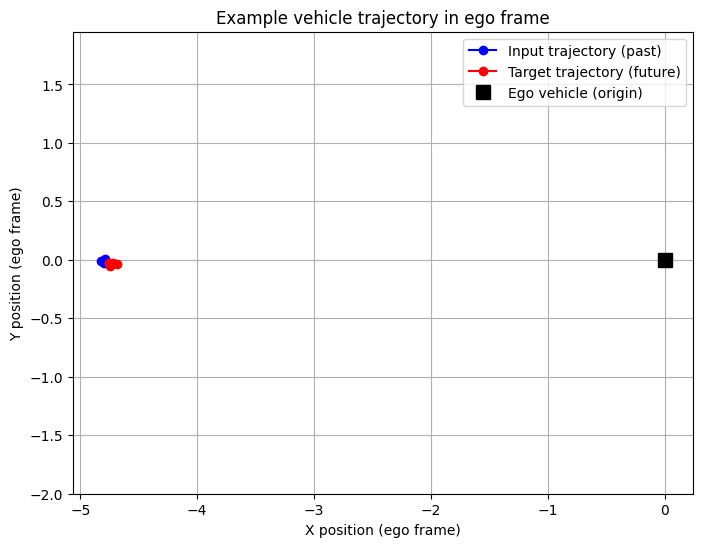

In [ ]:
print(f"Annotation tokens (sequenza completa) per sample {example_idx_to_visualize}:\n{ann_tokens_example}")
print("First token: ", first_ann_token)
print(f"Input sequence : {input_seq}, Target sequence : {target_seq}")
plt.figure(figsize=(8, 6))
plt.plot(input_seq[:, 0], input_seq[:, 1], 'bo-', label='Input trajectory (past)')
plt.plot(target_seq[:, 0], target_seq[:, 1], 'ro-', label='Target trajectory (future)')
plt.plot(0, 0, 'ks', markersize=10, label='Ego vehicle (origin)')
plt.legend()
plt.xlabel('X position (ego frame)')
plt.ylabel('Y position (ego frame)')
plt.title('Example vehicle trajectory in ego frame')
plt.grid(True)
plt.axis('equal')
plt.show()

# Mantieni l'ann_tokens per la visualizzazione successiva prendendolo dall'esempio visualizzato
ann_tokens = ann_tokens_example if example_idx_to_visualize < len(samples) else None

Render annotation

Annotation token del primo frame: 1ba2ea64ea5240239e30e2f5df7c92b5
Sample token per timestamp 1704027657.498: 8645dd1e937d48dfb703be785dee3145
8645dd1e937d48dfb703be785dee3145


AssertionError: Error: Could not find image where annotation is visible. Try using e.g. BoxVisibility.ANY.

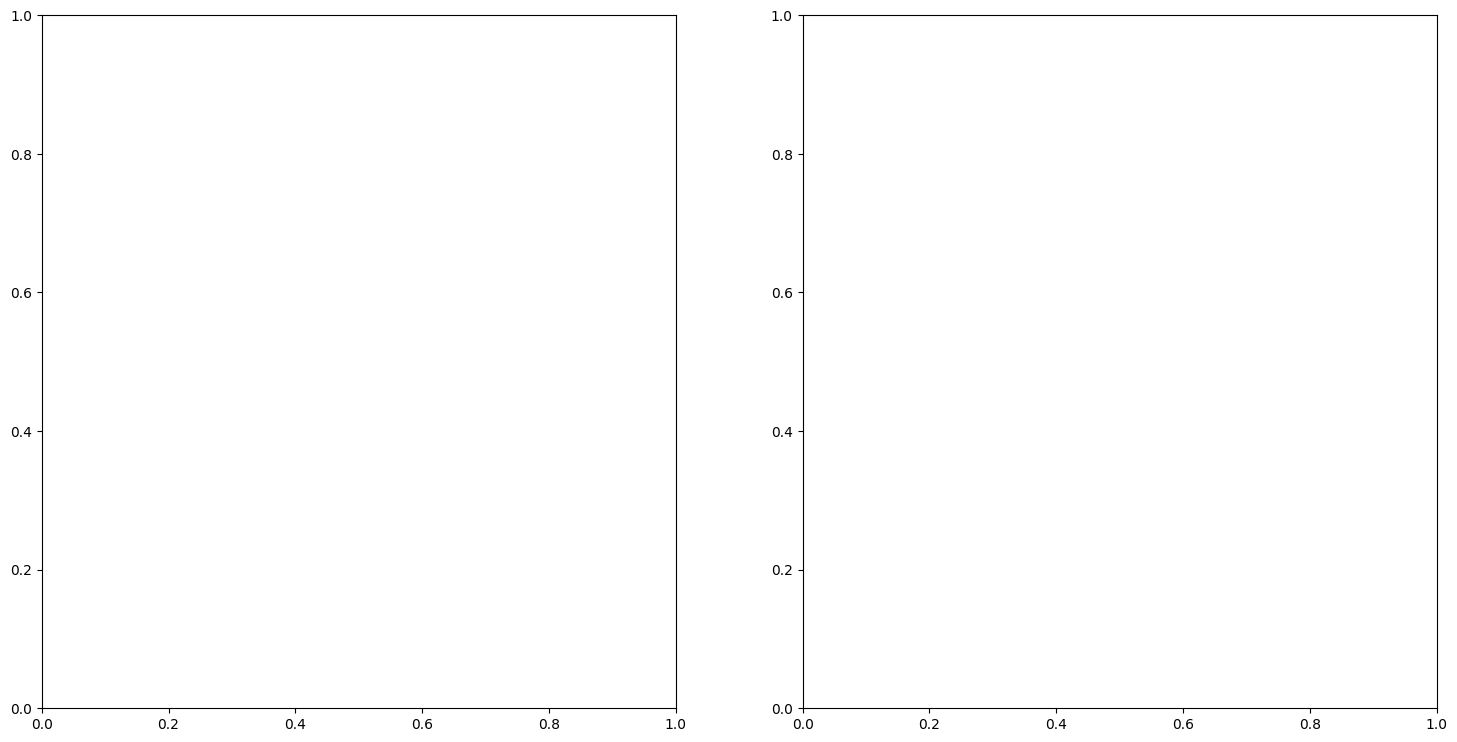

In [ ]:
# import box visibility
print(f"Annotation token del primo frame: {first_ann_token}")
first_timestamp = None
for entry in flat_data:  # 'data' è la lista dei dict da 'nearest_vehicle_trajectories.json'
    if entry['annotation_token'] == first_ann_token:
        first_timestamp = float(entry['timestamp'])
        break

if first_timestamp is None:
    raise ValueError("Timestamp non trovato per il primo annotation token")

rounded_ts = str(round(first_timestamp, 3))
sample_token = timestamp_to_sample.get(rounded_ts)
print(f"Sample token per timestamp {rounded_ts}: {sample_token}")
print(sample_token)
if sample_token is None:
    print(f"Nessun sample_token trovato per timestamp {rounded_ts}")
else:
    sample = trucksc.get('sample', sample_token)
    cam_token = sample['data']['CAMERA_RIGHT_FRONT']
    for ann_token in ann_tokens_example:
        trucksc.render_annotation(ann_token)


## Polynomial Regression

📈 Avg Trajectory Length: 6.557
📉 Avg MAE: 2.590
✅ Accuracy %: 60.51%
✅ matched sample: (array([[-4.30897429e+00, -4.37570235e-02],
       [-4.38735464e+00, -4.22355506e-03],
       [-4.36258611e+00, -4.93066312e-03]]), array([[-4.33589166, -0.04603388],
       [-4.37380618, -0.0279963 ],
       [-4.41559312, -0.02416814],
       [-4.28658432, -0.03354165],
       [-4.32302316, -0.04724295],
       [-4.42158887, -0.01656904],
       [-4.41519014, -0.0459898 ]]), ['1ba2ea64ea5240239e30e2f5df7c92b5', 'a2471250298b48b192e6ba2c6ec74ea5', 'ce2b836d1f4440a881d99d438fc67726', '396a962b52bc48389875601cab0fac42', '55bd883e5379497ea9e3a0b47ae925f8', 'e4a7f2b5f87545dcad7a7226067d4d4f', '940ca262f0ec4145a02684bce3e8cf4c', '42a2a5ace56e454088de902a8e8548c4', 'f4c9442f045a4b019bcc05fbe3a5da26', '63fa3ac75d014902b96b9300805693e7'], False)


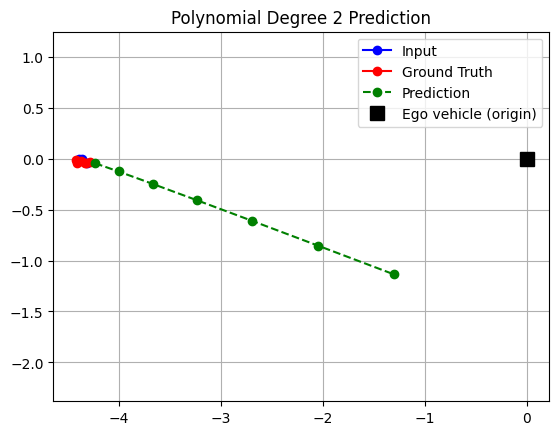

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def predict_polynomial(input_seq, pred_len=7, degree=2):
    input_len = input_seq.shape[0]
    t = np.arange(input_len)

    # Fit polynomials for x and y separately
    poly_x = np.poly1d(np.polyfit(t, input_seq[:, 0], deg=degree))
    poly_y = np.poly1d(np.polyfit(t, input_seq[:, 1], deg=degree))

    t_future = np.arange(input_len, input_len + pred_len)
    pred_x = poly_x(t_future)
    pred_y = poly_y(t_future)

    return np.stack([pred_x, pred_y], axis=1)

# --- Evaluate on your samples ---

def evaluate_polynomial_model(samples, degree=2, pred_len=7):
    errors = []
    lengths = []

    for input_seq, target_seq, ann_tokens, is_aug in samples:
        if is_aug:
            continue  # Skip augmented samples

        pred = predict_polynomial(input_seq, pred_len=pred_len, degree=degree)
        gt = np.array(target_seq)

        # MAE
        error = np.mean(np.linalg.norm(pred - gt, axis=1))
        traj_len = np.sum(np.linalg.norm(np.diff(gt, axis=0), axis=1))

        errors.append(error)
        lengths.append(traj_len)

    avg_error = np.mean(errors)
    avg_length = np.mean(lengths)
    accuracy_pct = (1 - avg_error / avg_length) * 100

    print(f"📈 Avg Trajectory Length: {avg_length:.3f}")
    print(f"📉 Avg MAE: {avg_error:.3f}")
    print(f"✅ Accuracy %: {accuracy_pct:.2f}%")
    return errors, lengths


def visualize_polynomial_prediction(sample, degree=2):
    input_seq, target_seq, _, _ = sample
    pred = predict_polynomial(np.array(input_seq), pred_len=len(target_seq), degree=degree)

    plt.plot(*np.array(input_seq).T, 'bo-', label='Input')
    plt.plot(*np.array(target_seq).T, 'ro-', label='Ground Truth')
    plt.plot(*pred.T, 'go--', label='Prediction')
    plt.plot(0, 0, 'ks', markersize=10, label='Ego vehicle (origin)')

    plt.title(f'Polynomial Degree {degree} Prediction')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Evaluate on your dataset
errors, lengths = evaluate_polynomial_model(samples)

# Optional: visualize one
for sample in samples:
        ann_tokens_window = sample[2]
        ann_token_entry = ann_tokens_window[0] # Access the first element of the ann_tokens_window list

        if isinstance(ann_token_entry, dict):
            if ann_token_entry.get('is_augmented', False):
                continue
            token_to_check = ann_token_entry.get('annotation_token', None)
        else:
            token_to_check = ann_token_entry

        if token_to_check == first_ann_token:
            matched_sample = sample
            print("✅ matched sample:", matched_sample)
            break
visualize_polynomial_prediction(matched_sample)


## LSTM

### Training

#### Without drop

In [ ]:
import importlib
import train

importlib.reload(train)  # Ricarica il file train.py

from train import train_model  # Ora prende la versione aggiornata
model, debug_preds = train_model(samples, num_epochs=300, batch_size=4, lr=0.001, mode = "save")


Lunghezza media traiettorie: 6.0949
MAE medio: 0.8212
Accuratezza percentuale: 86.53%

Predizioni salvate: 305 / 305 (non augmentati)



#### With drop

In [172]:
import importlib
import train_withdrop

importlib.reload(train)  # Ricarica il file train.py

from train_withdrop import train_model  # Ora prende la versione aggiornata
model, debug_preds = train_model(samples, num_epochs=50, batch_size=4, lr=0.001, mode = "save")


Epoch 1/50, Train Loss: 7.1700, Val Loss: 7.4267
Epoch 2/50, Train Loss: 5.8410, Val Loss: 6.1129
Epoch 3/50, Train Loss: 4.3325, Val Loss: 4.2981
Epoch 4/50, Train Loss: 2.6042, Val Loss: 2.9967
Epoch 5/50, Train Loss: 2.4393, Val Loss: 2.7777
Epoch 6/50, Train Loss: 2.1622, Val Loss: 3.6456
Epoch 7/50, Train Loss: 1.7574, Val Loss: 3.3578
Epoch 8/50, Train Loss: 2.0226, Val Loss: 1.7817
Epoch 9/50, Train Loss: 1.7619, Val Loss: 2.0716
Epoch 10/50, Train Loss: 1.5342, Val Loss: 1.6175
Epoch 11/50, Train Loss: 1.6970, Val Loss: 1.3000
Epoch 12/50, Train Loss: 1.3426, Val Loss: 0.9424
Epoch 13/50, Train Loss: 1.3671, Val Loss: 1.3851
Epoch 14/50, Train Loss: 1.1416, Val Loss: 1.0181
Epoch 15/50, Train Loss: 1.0546, Val Loss: 1.0917
Epoch 16/50, Train Loss: 1.1859, Val Loss: 1.8032
Epoch 17/50, Train Loss: 1.1601, Val Loss: 1.0450
Epoch 18/50, Train Loss: 0.9726, Val Loss: 0.8698
Epoch 19/50, Train Loss: 0.9863, Val Loss: 1.0170
Epoch 20/50, Train Loss: 1.0468, Val Loss: 0.9347
Epoch 21/

### Results

Visualizzazione nel piano cartesiano

In [173]:
import importlib
import data_visualization

importlib.reload(data_visualization)
from data_visualization import visualize_trajectory

# "ego" to visualize w.r.t Vehicle, "Global" for global visualization

matched_sample, input_seq, target_s, pred_seq = visualize_trajectory(trucksc, debug_preds,first_ann_token, mode="global")

First annotation token: 42b719587476418888f659c0215f3d47_
✅ matched sample: {'input': [[-5.580044746398926, 0.5250694751739502], [-5.729899883270264, 0.4488208591938019], [-5.788121223449707, 0.3683966100215912]], 'pred': [[-5.668409824371338, 0.5957468152046204], [-5.67988920211792, 0.6036537289619446], [-5.695008754730225, 0.6545872092247009], [-5.69273042678833, 0.661291778087616], [-5.685362339019775, 0.6132447123527527], [-5.670101165771484, 0.5289811491966248], [-5.648168087005615, 0.4391728341579437]], 'gt': [[-5.697466850280762, 0.1277695894241333], [-5.606231689453125, 0.13719415664672852], [-5.633161544799805, 0.17719505727291107], [nan, nan], [-5.675619125366211, 0.3888176679611206], [-5.703542709350586, 0.6041567325592041], [-5.751293659210205, 1.1440235376358032]], 'mask': [True, True, True, False, True, True, True], 'ann_tokens': ['42b719587476418888f659c0215f3d47_', 'c15cbb746c044a9bb2f5e11a8c67b902_', '54944328f76d43cfbdc9af6af3976452_', '54bd58c383e5405e9d8537ec3cc5360

KeyError: '42b719587476418888f659c0215f3d47_'

Box sovrapposti nella traiettoria

Box GT: label: nan, score: nan, xyz: [0.16, 0.20, -9.64], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.71, ang(rad): 2.04, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.55, 0.22, -10.93], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.71, ang(rad): 2.04, vel: nan, nan, nan, name: Prediction, token: None


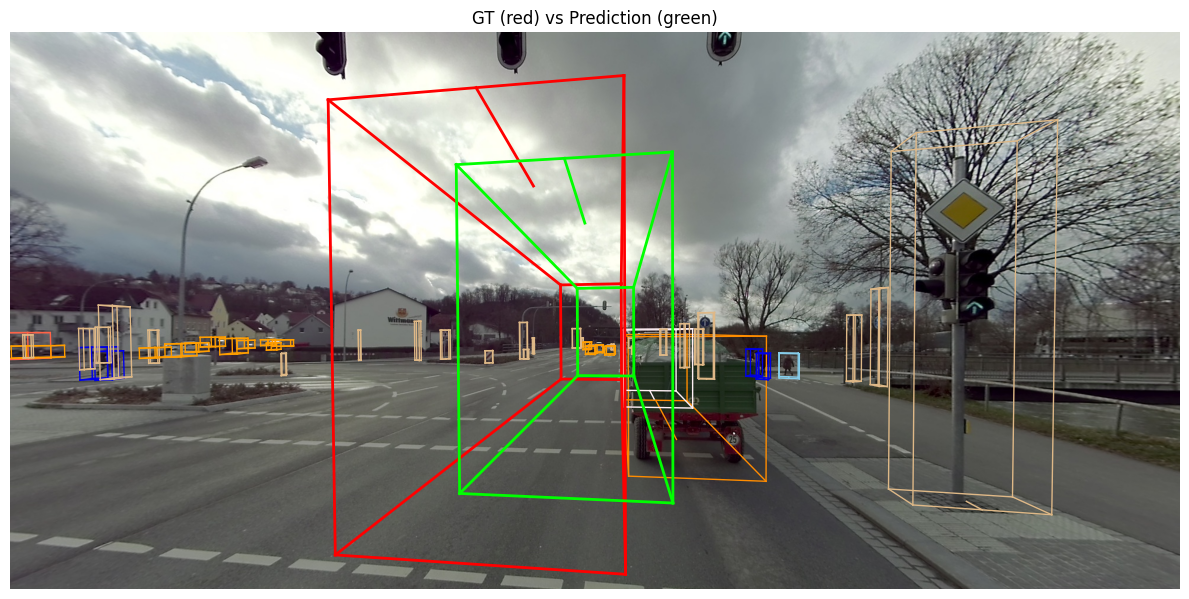

Box GT: label: nan, score: nan, xyz: [0.14, 0.22, -9.68], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.45, ang(rad): 2.03, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.58, 0.24, -10.93], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.45, ang(rad): 2.03, vel: nan, nan, nan, name: Prediction, token: None


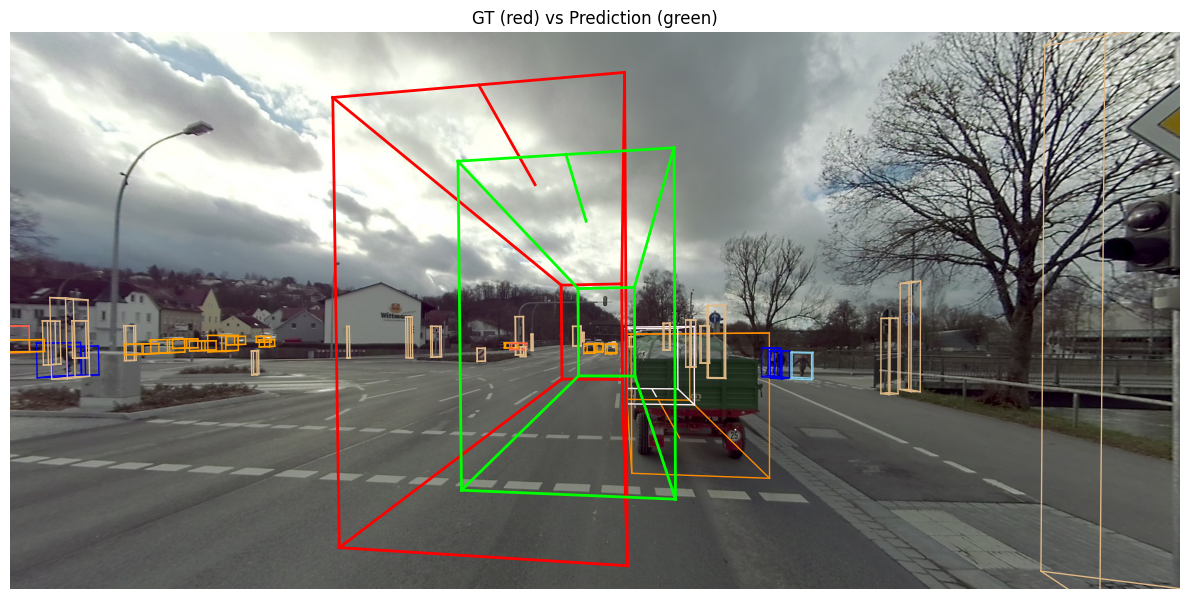

Box GT: label: nan, score: nan, xyz: [0.13, 0.23, -9.72], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.34, ang(rad): 2.03, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.56, 0.25, -10.92], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.34, ang(rad): 2.03, vel: nan, nan, nan, name: Prediction, token: None


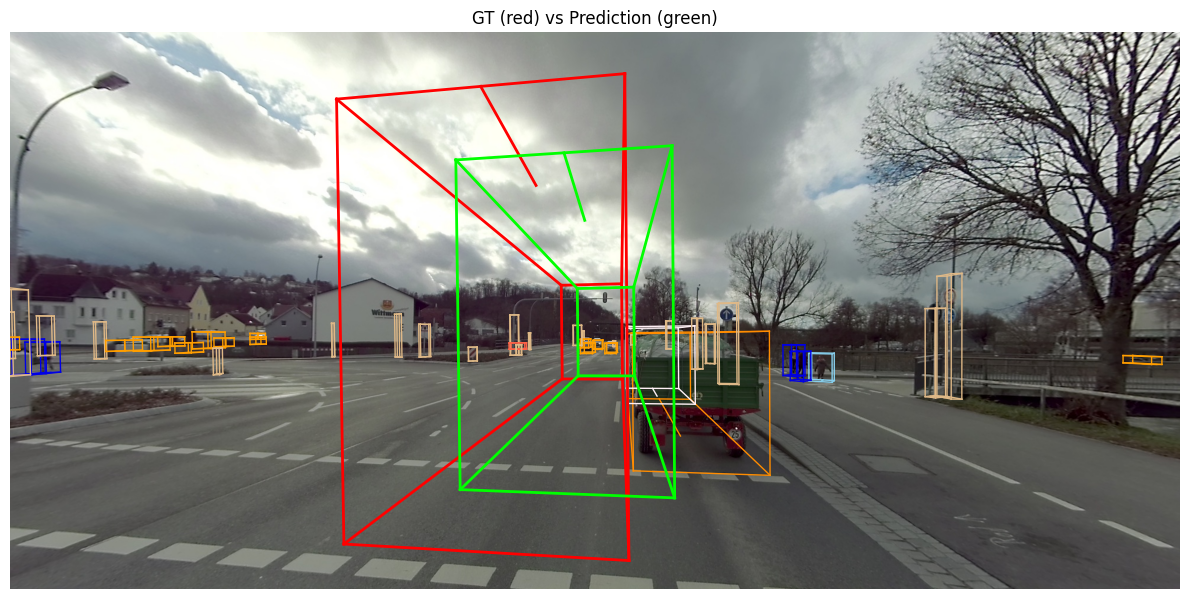

Box GT: label: nan, score: nan, xyz: [0.15, 0.24, -9.59], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.28, ang(rad): 2.03, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.54, 0.26, -10.89], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.28, ang(rad): 2.03, vel: nan, nan, nan, name: Prediction, token: None


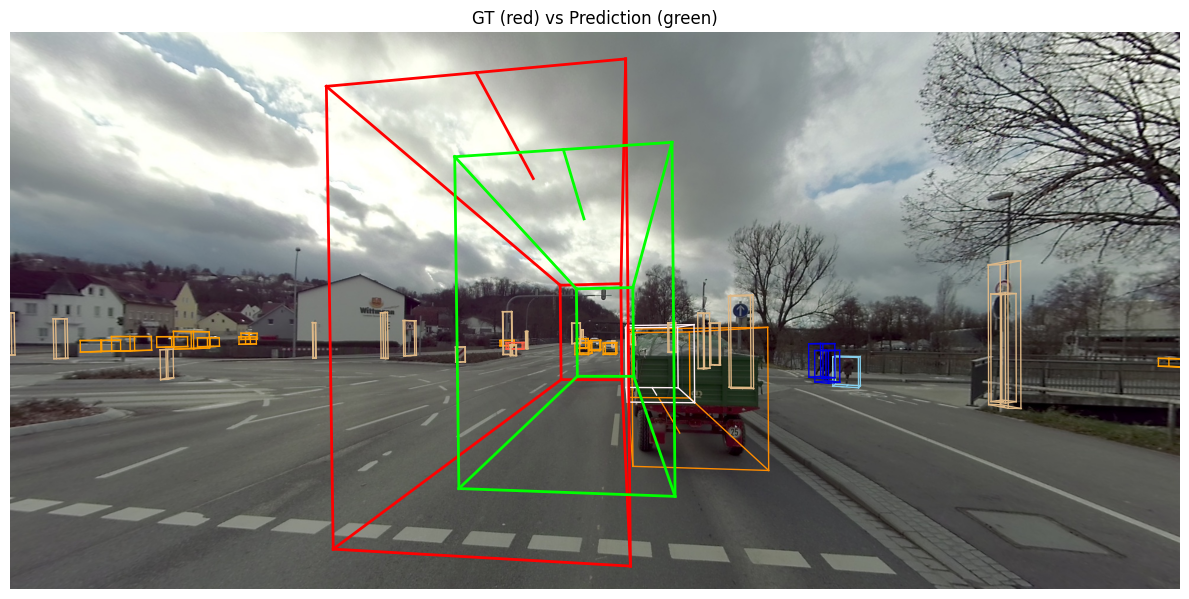

Box GT: label: nan, score: nan, xyz: [0.16, 0.19, -9.63], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.32, ang(rad): 2.03, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.52, 0.20, -10.87], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.32, ang(rad): 2.03, vel: nan, nan, nan, name: Prediction, token: None


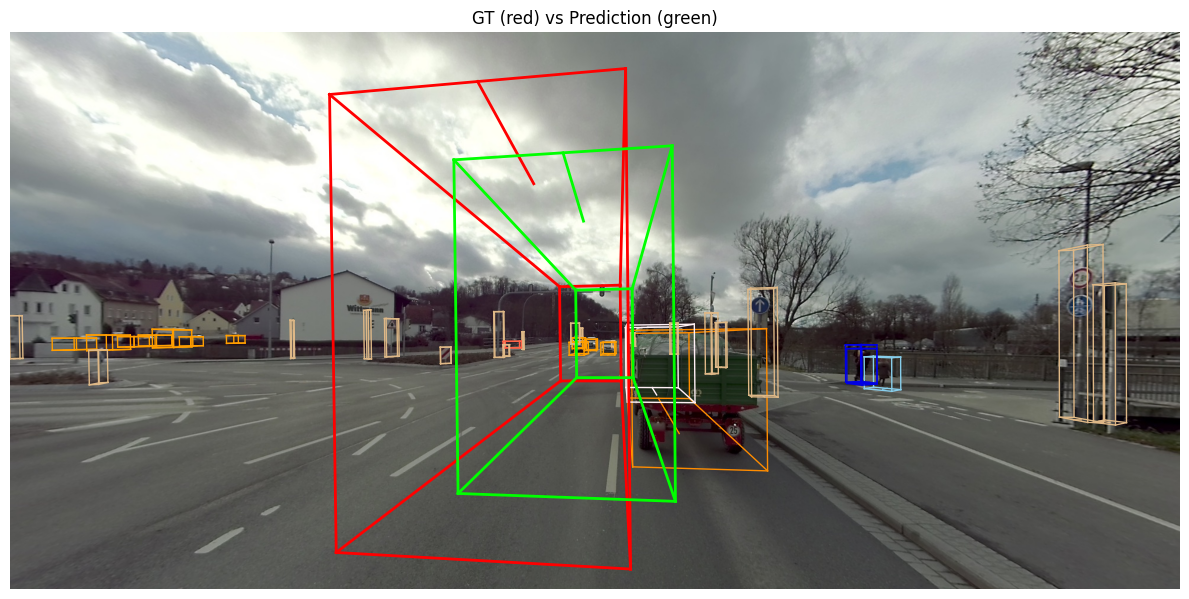

Box GT: label: nan, score: nan, xyz: [0.12, 0.22, -9.73], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.02, ang(rad): 2.02, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.51, 0.23, -10.86], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.02, ang(rad): 2.02, vel: nan, nan, nan, name: Prediction, token: None


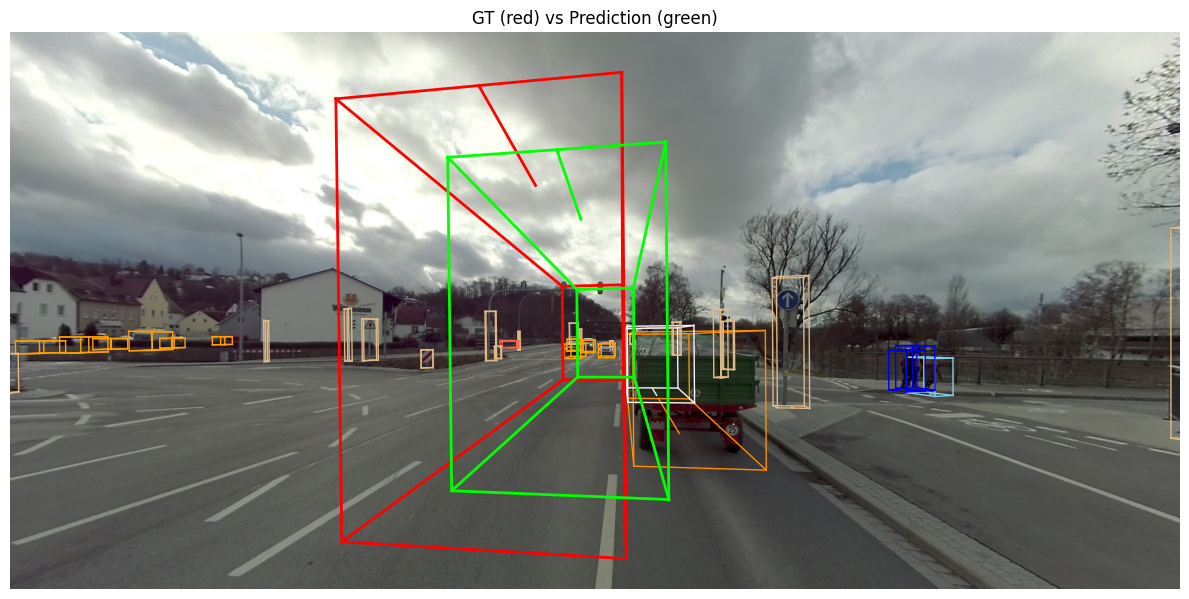

Box GT: label: nan, score: nan, xyz: [0.15, 0.25, -9.72], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.04, ang(rad): 2.03, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.50, 0.26, -10.84], wlh: [2.58, 12.96, 4.04], rot axis: [0.62, -0.56, 0.55], ang(degrees): 116.04, ang(rad): 2.03, vel: nan, nan, nan, name: Prediction, token: None


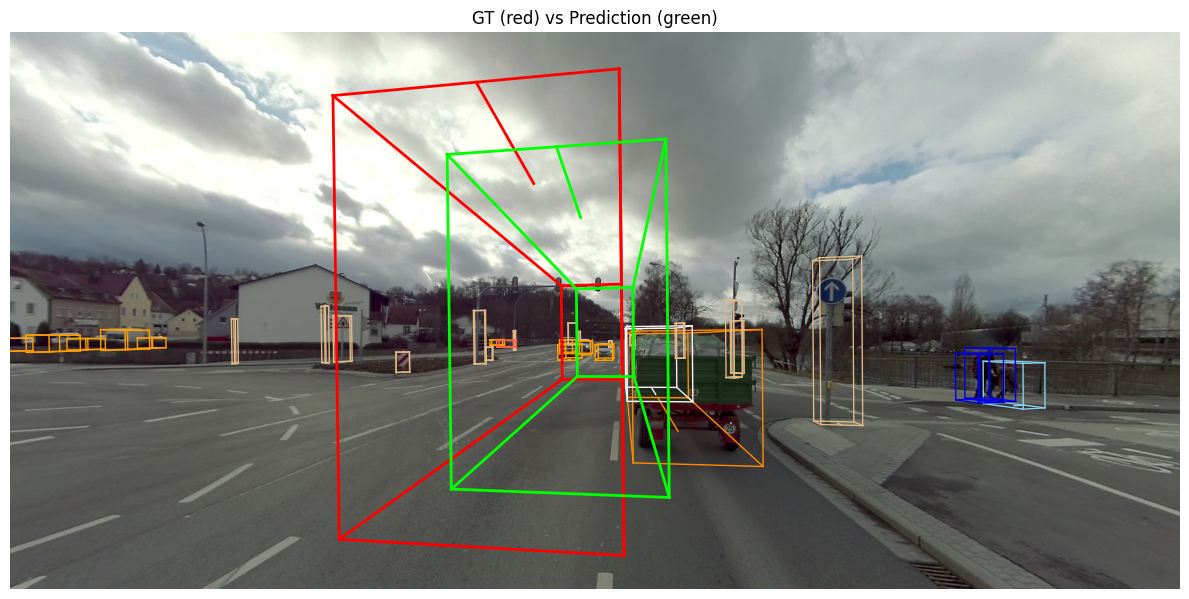

In [ ]:
import importlib
import data_visualization

importlib.reload(data_visualization)
from data_visualization import render_box
render_box(trucksc, pred_seq, matched_sample)

Intera traiettoria a partire dal primo frame

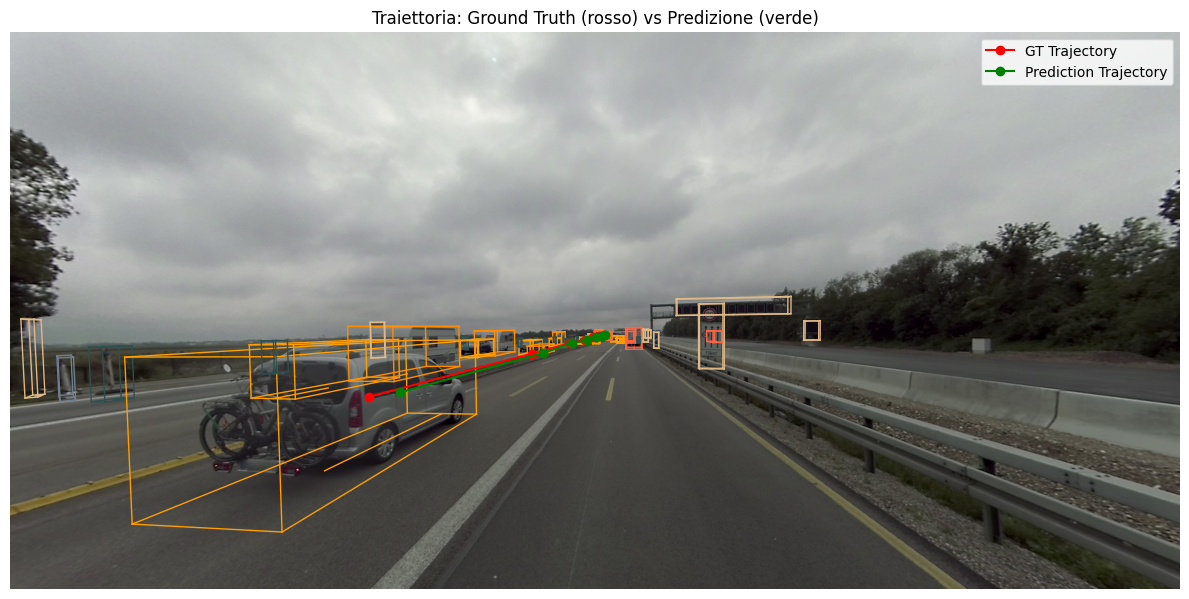

In [ ]:
import importlib
import data_visualization

importlib.reload(data_visualization)
from data_visualization import render_trajectory

render_trajectory(trucksc, matched_sample, pred_seq)